In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, spectrogram, square, peak_prominences
from scipy.fft import fftshift, rfft
from matplotlib.ticker import FuncFormatter
import matplotlib.axes as ax
from zipfile import ZipFile
import gc

pd.options.mode.copy_on_write = True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


EXTRACCION COMPRIMIDOS TAR.GZ

In [ ]:
import gzip
import io
import tarfile

def read_csv_from_tar_gz(tar_gz_file, folder_name, csv_file_to_select):
    try:
        # Abrir el archivo .tar.gz en modo lectura
        with gzip.open(tar_gz_file, 'rb') as gz_file:
            # Descomprimir el contenido del archivo .tar.gz
            with tarfile.open(fileobj=gz_file, mode='r') as tar:
                # Recorrer todos los miembros del archivo .tar.gz
                for member in tar.getmembers():
                    # Verificar si el miembro es un archivo y está dentro de la carpeta "muons"
                    if member.isfile() and folder_name in member.name:
                        # Extraer el nombre del archivo del miembro
                        filename = member.name.split('/')[-1]  # Obtenemos solo el nombre del archivo
                        # Verificar si el archivo es un archivo .csv y coincide con el archivo deseado
                        if filename == csv_file_to_select:
                            # Leer el contenido del archivo
                            file_content = tar.extractfile(member).read().decode('utf-8')
                            # Convertir el contenido a un objeto StringIO para poder leerlo con el módulo csv
                            file_content_io = io.StringIO(file_content)
                            # Leer el archivo CSV utilizando el módulo csv, omitiendo las primeras 100 filas
                            df = pd.read_csv(file_content_io, skiprows=103)
                            return df  # Devolver el DataFrame
                print(f"No se encontró el archivo {csv_file_to_select} en la carpeta {folder_name}")
    except (gzip.BadGzipFile, tarfile.TarError) as e:
        print(f"Error al leer el archivo {tar_gz_file}: {e}")

# Ruta del archivo .tar.gz
tar_gz_file = r"/content/drive/MyDrive/Labo 6/Mediciones_dark_noise/Medicion2.zip"

# Nombre de la carpeta que contiene los archivos .csv
folder_name = 'Medicion2'

# Nombre del archivo .csv que deseas seleccionar
csv_file_to_select = 'C1muons-Botti-1610-100Samples00001.csv'

# Llamar a la función para leer el archivo CSV y devolver un DataFrame, omitiendo las primeras 100 filas
df = read_csv_from_tar_gz(tar_gz_file, folder_name, csv_file_to_select)

# Verificar si se devolvió un DataFrame correctamente
if df is not None:
    # Realizar operaciones con el DataFrame
    # Por ejemplo, puedes utilizar df.head() para verificar las primeras filas del DataFrame
    print(df.head())
else:
    print("No se pudo leer el archivo CSV correctamente.")

Error al leer el archivo /content/drive/MyDrive/Labo 6/Mediciones_dark_noise/Medicion2.zip: Not a gzipped file (b'\x14\x00')
No se pudo leer el archivo CSV correctamente.


EXTRACCION COMPRIMIDOS ZIP

In [ ]:
import zipfile

# Path to the zip file
zip_file_path = "/content/drive/MyDrive/Labo 6/Mediciones_dark_noise/Cesar_Martin.zip"

path_extract = '/content/Extracto'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract all files in the zip file
    zip_ref.extractall(path_extract)

# Print a message to indicate that the files have been extracted
print(f"Archivos Extraidos a {path_extract}")


Archivos Extraidos a /content/Extracto


COMPRIME ARCHIVOS DE DIRECTORIO PARA DESCARGA

In [ ]:
!zip -r /content/picos.zip /content/Picos

BATCH DE DETECCION

C4dark-noise00000.csv


<ipython-input-7-94c57742438e>:46: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  datos = pd.read_csv(os.path.join(carpeta, archivo), low_memory=True)


KeyboardInterrupt: 

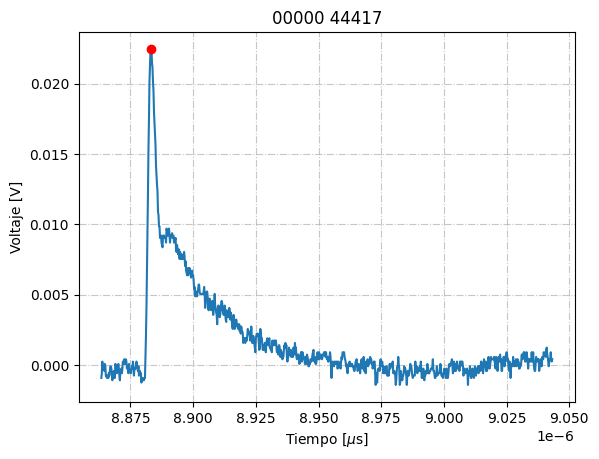

In [ ]:
import psutil

carpeta = r'/content/Extracto/Cesar y Martin/Medicion1'
picos_dir = r'/content/Picos'


def get_last_numbers(filename):
  return int(filename.split('.')[0][-5:])

arch_dir = [f for f in os.listdir(carpeta) if f.endswith('.csv')]
arch_dir.sort(key=get_last_numbers)

#arch_dir = [os.path.join(carpeta,'C4dark-noise00013.csv')]

if not os.path.exists(picos_dir):
    os.makedirs(picos_dir)

# # Diccionario para excepciones de archivos
# excepciones_datos = {
#     'C2muon-botti-2-1000000.csv': slice(1003, -1)
# }

# diccionario para estadistica de picos
dict_picos_arch = {}
#diccionario de mediciones simples
dict_simples = {}

dict_coincidencias = {}

#quita archivos que estan mal ploteados
#excepciones_csv = ['C1muon-botti-2-1000000.csv','C1muons-Botti-1610-1000Samples00000.csv']

seccion_modelo=[]

plot_pulsos = True
low_memory_pd = True

for archivo in arch_dir:
    if archivo.endswith('.csv'):
      ram_usg_perc = psutil.virtual_memory()[2]
      if ram_usg_perc > 90:
        break
      else:
        pass
      print(archivo)
      dict_simples[archivo] = []
      datos = pd.read_csv(os.path.join(carpeta, archivo), low_memory=low_memory_pd)
      muones = datos.iloc[5003:]
      muones.reset_index(inplace=True)
      muones = muones.rename(columns={muones.columns[0]: "t", muones.columns[1]: "V"})
      muones.loc[:, 't'] = muones['t'].astype('float')
      muones.loc[:, 'V'] = muones['V'].astype('float')*-1
      muones.drop(columns=['67688','Waveform'])
      delta_t = muones['t'].iloc[1] - muones['t'].iloc[0]
      tiempo = [i * delta_t for i in range(len(muones))]
      muones['t_0'] = pd.Series(tiempo)

      # Encuentra picos en los datos
      picos = find_peaks(muones['V'], prominence=.02, distance=500)
      picos_v = picos[1]['prominences']
      picos_t = picos[0]

      picos_v_filtrados = picos_v[[i for i, t in enumerate(picos_t) if t in muones['t_0'].index]]
      picos_t_filtrados = picos_t[[i for i, t in enumerate(picos_t) if t in muones['t_0'].index]]

      dict_coincidencias[archivo] = len(picos_v)

      plt.close()  # Cierra cualquier gráfico previo antes de iniciar uno nuevo
      plt.grid(linestyle='-.', alpha=0.7)
      plt.ylabel('Voltaje [V]')
      plt.xlabel(r'Tiempo [$\mu$s]')
      plt.plot(muones['t_0'], muones['V'])
      plt.plot(muones['t_0'][picos_t_filtrados], picos_v_filtrados, 'o')
      arch_sin_csv = archivo.split('.csv')[0]
      plt.title(arch_sin_csv.split(carpeta+'/')[-1].split('C4dark-noise')[-1])
      plt.savefig(os.path.join(picos_dir,f'picos_csv_{arch_sin_csv}.png'))
      #plt.savefig('/content/Picos/13.png')

      # Estadísticas de picos
      try:
        dict_picos_arch[archivo] = [np.mean(picos_v), np.max(picos_v), np.min(picos_v), np.std(picos_v)]
      except:
        pass
      dict_ventanas = {}

      # Busca picos dentro de cada ventana
      for key_pulso in picos_t:
        borde_izq = 400
        if key_pulso < borde_izq:
            seccion = np.array(range(key_pulso, key_pulso + 900))
            dict_muestras = {key_pulso: seccion}
        else:
            seccion = np.array(range(key_pulso - 100, key_pulso + 800))
            dict_muestras = {key_pulso: seccion}

        # Ajustamos la selección de datos para cada ventana
        idx_inicio = dict_muestras[key_pulso][0] - muones.index[0]
        idx_fin = dict_muestras[key_pulso][-1] - muones.index[0] + 1

        pulso_t_0 = muones['t_0'].iloc[idx_inicio:idx_fin]
        pulso_v = muones['V'].iloc[idx_inicio:idx_fin]
        #picos_ventana = find_peaks(pulso_v, height=0.0001,prominence=0.003)               #funciona para 0000.csv
        picos_ventana = find_peaks(pulso_v, height=0.0001,prominence=0.004)
        # Solo para debugging
        #print(key_pulso, 'Cantidad de picos por ventana:', len(picos_ventana[0]))
        if len(picos_ventana[0]) == 1:
          ancho = 20
          ubic_pico = picos_ventana[0][0]
          picos_vent_v = picos_ventana[1]['prominences']
          picos_vent_t = picos_ventana[0]
          if (pulso_v.iloc[ubic_pico-ancho//2]==pulso_v.iloc[ubic_pico]) and (pulso_v.iloc[ubic_pico+ancho//2]== pulso_v.iloc[ubic_pico]):
            print('Saturado')
            continue
          else:
            picos_vent_v = picos_ventana[1]['prominences']
            picos_vent_t = picos_ventana[0]
            dict_ventanas[key_pulso] = picos_ventana[0]
            dict_simples[archivo].append({key_pulso: pulso_t_0.iloc[picos_vent_t].index, 'pulso_vent_t_v': [pulso_t_0,pulso_v]})
            if plot_pulsos==True:
              plt.close()  # Cierra cualquier gráfico previo antes de iniciar uno nuevo
              plt.grid(linestyle='-.', alpha=0.7)
              plt.ylabel('Voltaje [V]')
              plt.xlabel(r'Tiempo [$\mu$s]')
              plt.plot(pulso_t_0, pulso_v)
              plt.scatter(pulso_t_0.iloc[picos_vent_t], pulso_v.iloc[picos_vent_t], color='red', zorder=99)
              n_arch = archivo.split('.csv')[0].split('C4dark-noise')[-1]
              plt.title(n_arch+' '+f'{key_pulso}')
              plt.savefig(os.path.join(picos_dir,f'pico_{n_arch}_{key_pulso}.png'))
      del muones, picos, picos_v, picos_t, picos_v_filtrados, picos_t_filtrados
      gc.collect()


del ancho, arch_sin_csv, picos_ventana, borde_izq, key_pulso, dict_picos_arch, datos, picos_dir

In [ ]:
datos = pd.read_csv(r'/content/Extracto/Cesar y Martin/Medicion1/C4dark-noise00000.csv',skiprows=5003)

In [ ]:
datos

,Time,Ampl
0,-6.615380e-08,-0.000395
1,-6.595380e-08,-0.000229
2,-6.575380e-08,-0.000893
3,-6.555380e-08,-0.000727
4,-6.535380e-08,-0.000561
...,...,...
5009104,1.332980e-07,-0.001724
5009105,1.334980e-07,-0.000893
5009106,1.336980e-07,-0.000561
5009107,1.338980e-07,-0.000395


ESTADISTICA DE PICOS SIMPLES

In [ ]:
#dict_simples-----> diccionario con values tipo lista
#dict_simples['C4dark-noise00000.csv'][i]['pulso_vent_t_v'][1]-----> serie voltajes
#dict_simples['C4dark-noise00000.csv'][i]['pulso_vent_t_v'][1]-----> serie temporal

#prom_arch = np.mean([np.mean(dict_simples['C4dark-noise00000.csv'][i]['pulso_vent_t_v'][1]) for i in range(len(dict_simples['C4dark-noise00000.csv']))])

stats_lst = []

#limpia los dataframes vacios
for key in list(dict_simples.keys()):
    if not dict_simples[key]:
        dict_simples.pop(key)

for archivo in dict_simples.keys():
  print(archivo)
  prom_arch = []
  for pico in range(len(dict_simples[archivo])):

    #cada maximo es un pico
    max_pico_arch = np.max(dict_simples[archivo][pico]['pulso_vent_t_v'][1])
    #print(max_pico_arch)
    prom_arch.append(max_pico_arch)

  stats_lst.append(prom_arch)


prom_dict = np.mean([np.mean(stats_lst[i]) for i in range(len(stats_lst))])
max_dict = np.max([np.max(stats_lst[i]) for i in range(len(stats_lst))])
min_dict = np.min([np.min(stats_lst[i]) for i in range(len(stats_lst))])
std_dict = np.max([np.std(stats_lst[i]) for i in range(len(stats_lst))])
print('promedio de todos los csv: ' + str(round(prom_dict,5))+'V',
      '\n min de un pico entre todos los csv: '+str(round(min_dict,5))+'V',
      '\n max de un pico entre de todos los csv: '+str(round(max_dict,5))+'V',
      '\n max std de los max entre todos los csv: '+str(round(std_dict,5))+'V')


C4dark-noise00007.csv
C4dark-noise00000.csv
C4dark-noise00002.csv
C4dark-noise00009.csv
C4dark-noise00008.csv
C4dark-noise00012.csv
C4dark-noise00010.csv
C4dark-noise00005.csv
C4dark-noise00004.csv
C4dark-noise00003.csv
C4dark-noise00001.csv
C4dark-noise00006.csv
C4dark-noise00011.csv
promedio de todos los csv: 0.04492V 
 min de un pico entre todos los csv: 0.01949V 
 max de un pico entre de todos los csv: 0.11084V 
 max std de los max entre todos los csv: 0.01111V


LA DETECCION DE PICOS DECRECE CON EL VOLTAJE DE POLARIZACION (A PROMINENCE FIJA)

Text(0.5, 1.0, 'Cantidad de detecciones simples (prominence = .02)')

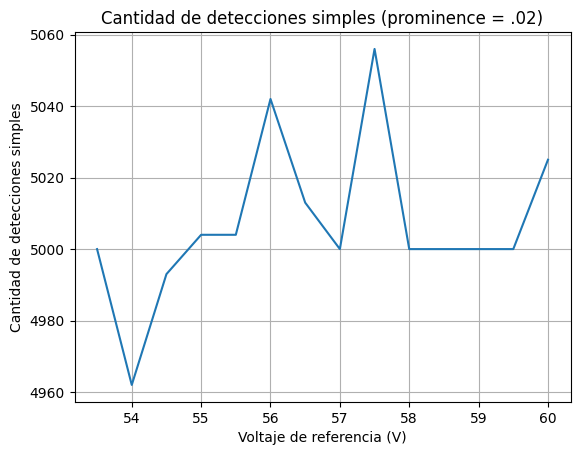

In [ ]:
keys = list(dict_coincidencias.keys())
numb_from_keys = [int(keys[i].split('C4dark-noise')[1].split('.csv')[0]) for i in range(len(keys))].sort()

arch_dir_v = [arch_dir[i] for i in range(len(arch_dir)) if arch_dir[i].endswith('.csv')]
arch_dir_v = sorted(arch_dir_v, key=lambda x: int(x.split('C4dark-noise')[1].split('.csv')[0]))
volts = [53.5,54,54.5,55,55.5,56,56.5,57,57.5,58,58.5,59,59.5,60]
dict_voltajes = dict((arch_dir_v[i],volts[i]) for i in range(len(volts)))


plt.plot(dict_voltajes.values(),dict_coincidencias.values())
plt.xlabel('Voltaje de referencia (V)')
plt.ylabel('Cantidad de detecciones simples')
#plt.plot(numb_from_keys,dict_coincidencias.values())
plt.grid()
plt.title('Cantidad de detecciones simples (prominence = .02)')

In [ ]:
carp = r'/content/Extracto/Cesar y Martin/Medicion1'
os.chdir(carp)
lis_arch = os.listdir(carp)
lis_tam_arch = [os.path.getsize(lis_arch[i]) for i in range(len(lis_arch))]

print(lis_arch[lis_tam_arch.index(max(lis_tam_arch))],lis_tam_arch.index(max(lis_tam_arch)))

C4dark-noise00003.csv 10


BORRA ARCHIVOS

In [ ]:
arch = os.listdir(picos_dir)
os.chdir(picos_dir)
for i in range(len(arch)):
  if arch[i].endswith('.png'):
    os.remove(arch[i])

BATCH DE MEDICIONES SIMPLES SIN CLIPPING

---



KeyboardInterrupt: 

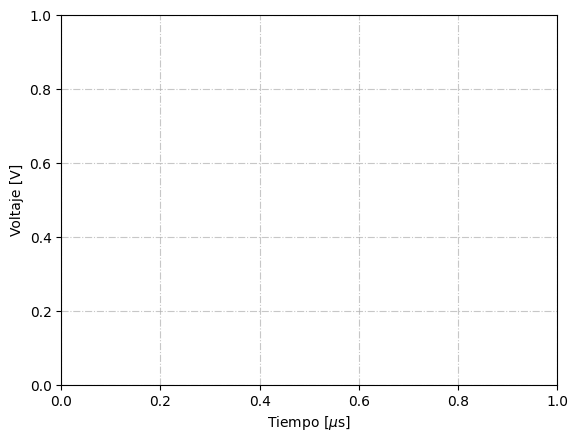

In [ ]:

carpeta = r'C:\Users\Martin\Desktop\Labo 6\Cesar y Martin\Medicion1'
picos_dir = r'C:\Users\Martin\Desktop\Labo 6\Cesar y Martin\Medicion1\Picos'

prominences_dict = {'C4dark-noise00000.csv': 0.02,'C4dark-noise00001.csv':0.02,'C4dark-noise00013.csv':0.02}

archivo = 'C4dark-noise00013.csv'

datos = pd.read_csv(os.path.join(carpeta, archivo), low_memory=False)
muones = datos.iloc[5003:]
muones.reset_index(inplace=True)
muones = muones.rename(columns={muones.columns[0]: "t", muones.columns[1]: "V"})
muones.loc[:, 't'] = muones['t'].astype('float')
muones.loc[:, 'V'] = muones['V'].astype('float')*-1
muones.drop(columns=['67688','Waveform'])
delta_t = muones['t'].iloc[1] - muones['t'].iloc[0]
tiempo = [i * delta_t for i in range(len(muones))]
muones['t_0'] = pd.Series(tiempo)


# Encuentra picos en los datos
picos = find_peaks(muones['V'], prominence=prominences_dict[archivo], distance=500)
picos_v = picos[1]['prominences']
picos_t = picos[0]

picos_v_filtrados = picos_v[[i for i, t in enumerate(picos_t) if t in muones['t_0'].index]]
picos_t_filtrados = picos_t[[i for i, t in enumerate(picos_t) if t in muones['t_0'].index]]

plt.close()  # Cierra cualquier gráfico previo antes de iniciar uno nuevo
plt.grid(linestyle='-.', alpha=0.7)
plt.ylabel('Voltaje [V]')
plt.xlabel(r'Tiempo [$\mu$s]')
plt.plot(muones['t_0'], muones['V'])
plt.plot(muones['t_0'][picos_t_filtrados], picos_v_filtrados, 'o')
#plt.xlim(.000002,.0000022)
#plt.ylim(0,.25)
arch_sin_csv = archivo.split('.csv')[0]
plt.title(f'{archivo}')
plt.savefig(os.path.join(picos_dir,f'picos_csv_{arch_sin_csv}.png'))



BATCH DE ANALISIS DE RISE-TIME 10%-90%

DEFINO FUNCIONES

In [ ]:
def fft_rv(v_array):
  """
  Devuelve la Transformada de Fourier real dado un array de tensiones (pandas.Series).

  v_array: array

  return:
  freqs: array de frecuencias de la serie temporal.
  fft_amp: array de valores de potencia de la serie temporal
  """
  #hago fft de la muestra
  fft_v = fft.rfft(v_array)
  #hago shift del valor absoluto de la parte real de la transformada fft y shift temporal
  fft_amp = np.abs(fft_v)
  #fft_v_real_sf = fft.fftshift(np.abs(fft_v))
  freqs = fft.rfftfreq(len(pulso_t_0),delta_t)
  return freqs,fft_amp



def potencia(v_array):
  """
  Devuelve la potencia eléctrica total dada una ventana de medición.

  v_array: ensiones de la ventana temporal, array.
  return: p_total, float.
  """
  R = 50
  p_array = v_array**2/R
  p_total = np.sum(p_array)
  return p_total

def risetime(t_array,v_array):
  """
  Calcula el rise-time de una ventana de medición tomado entre el 10% y el 90% del valor de amplitud de la señal.

  t_array: valores temporales, array.
  v_array: tensiones de la ventana temporal, array.

  return:
  rs_time: valor de rise-time, float.
  idx_rs: numpy array de los indices de donde se calcula el rise-time.
  idx_90: indice aproximado del v_array del 90% de la amplitud de la señal, float.
  """
  #INDICE DEL MAXIMO DEL PICO

  idx_max_total = np.where(v_array==max(v_array))[0]+v_array.index[0]
  idx_max = np.where(v_array==max(v_array))[0]

  promin = peak_prominences(v_array,idx_max)
  #devuelve left y right
  left_promin =  promin[1][0]
  if left_promin==0:
    max_ruido_left = np.mean(v_array)*.1
    #cambiar max_ruido_left a promedio de la señal si left_promin==0.
  else:
    #print(left_promin)
    max_ruido_left = np.max(v_array[:left_promin])
  #calcula diferencia entre pico y piso de ruido del lado izquierdo
  dif_pico_ruido = v_array[idx_max_total].values-max_ruido_left
  v_90 = dif_pico_ruido[0]*.9
  v_10 = dif_pico_ruido[0]*.1
  #estima el error entre el 90% y los valores presentes en v_array para hallar el mas proximo
  diferencias_abs = np.abs(v_array - v_90)
  #halla el indice mas cercano
  idx_90 = np.argmin(diferencias_abs)
  idx_rs = np.where((v_array >= v_10) & (v_array <= v_90))[0]
  rs_time = t_array[idx_rs[-1]+v_array.index[0]]-t_array[idx_rs[0]+v_array.index[0]]
  return rs_time, idx_rs, idx_90

In [ ]:

#toma dos pandas series devuelve dos pandas series
def transferencia(v_array,idx_corte):
  """
  Devuelve la transferencia resultante de dividir la potencia original y la potencia de la señal filtrada y Transformada por Fourier. Además devuelve la señal transformada luego del filtro.

  v_array: tensiones como serie temporal, pandas Series array.
  idx_corte: indice de corte del slice de frecuencias post transformada. Relacionado con la frecuencia, integer.
  return:
  freqs: array de frecuencias de la serie temporal.
  fft_amp: array de valores de potencia de la serie temporal
  """
  fft_v = fft.rfft(v_array)
  fft_v_real_sf = np.abs(fft_v)
  freqs = fft.rfftfreq(len(pulso_t_0),delta_t)
  fft_90 = fft_v[0:idx_corte]
  p_total = potencia(v_array)
  ifft_v = fft.irfft(fft_90,len(pulso_v))
  #recalculo potencia para la señal post corte
  p_90 = potencia(ifft_v)
  #recuerdo que pulso_t_0 es la parte temporal del dataframe total
  ifft_t = pulso_t_0[0:len(ifft_v)]
  transf = p_90/p_total
  #exporta como pandas Series
  ifft_v = pd.Series(ifft_v, ifft_t.index)
  return transf, ifft_t, ifft_v, freqs[idx_corte], p_90


CREO DICCIONARIO CON LOS RISE TIME CALCULADOS

In [ ]:
#calcula rise time de picos simples para todos los csv
rs_csv = {}

for k in dict_simples.keys():
  ser_temp = dict_simples[k][0]['pulso_vent_t_v'][0]
  ser_volt = dict_simples[k][0]['pulso_vent_t_v'][1]
  rs_csv[k] = risetime(ser_temp,ser_volt)[0]

#estadistica de rise-time
prom_rs = np.mean(list(rs_csv.values()))
std_rs = np.std(list(rs_csv.values()))

<ipython-input-14-b52b470511c3>:50: PeakPropertyWarning: some peaks have a prominence of 0
  promin = peak_prominences(v_array,idx_max)


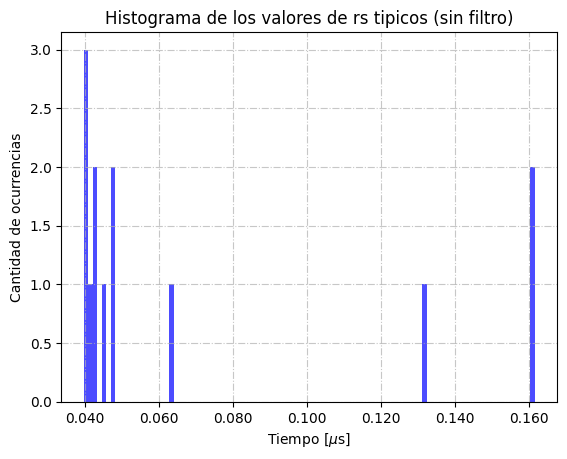

In [ ]:
import scipy.stats as stats
import math

# Extrae los valores del diccionario
values = list(rs_csv.values())

# Crea el histograma
plt.hist(values, bins=100, color='blue', alpha=0.7)

formatterx = FuncFormatter(lambda x, _: f"{x*10**6:.3f}")
plt.gca().xaxis.set_major_formatter(formatterx)

plt.xlabel('Tiempo [$\mu$s]')
plt.ylabel('Cantidad de ocurrencias')
plt.title('Histograma de los valores de rs tipicos (sin filtro)')
plt.grid(linestyle='-.',alpha=.7)
plt.show()


BATCH DE FRECUENCIA DE CORTE

0.8685866877983103 0.05307019990100095


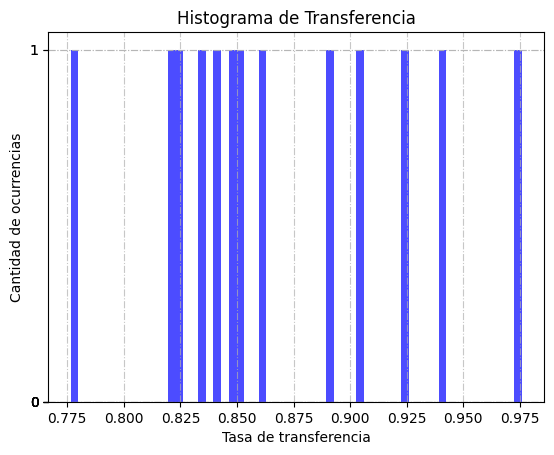

In [ ]:
#np.mean([transferencia(dict_simples[i]['pulso_vent_t_v'][1],15)[4]/potencia(dict_simples[i]['pulso_vent_t_v'][1]) for i in dict_simples.keys()])
#dict_simples
idx_corte = 15

#calculo std y mean de potencia
p_90_array = np.array([transferencia(dict_simples[i][0]['pulso_vent_t_v'][1],idx_corte)[4] for i in dict_simples.keys()])
p_total_array = np.array([potencia(dict_simples[i][0]['pulso_vent_t_v'][1]) for i in dict_simples.keys()])
transf_ = p_90_array/p_total_array
mean_transf_ = np.mean(transf_)
std_transf_ = np.std(transf_)
print(mean_transf_,std_transf_)

# Extrae los valores del diccionario
values = list(transf_)

# Crea el histograma
plt.hist(values, bins=60, color='blue', alpha=0.7)
plt.xlabel('Tasa de transferencia')
plt.ylabel('Cantidad de ocurrencias')
plt.title('Histograma de Transferencia')
plt.grid(linestyle='-.',alpha=.7)
#hace que los
yint = []
locs, labels = plt.yticks()
yint = [int(y) for y in locs]
plt.yticks(yint)
plt.show()



In [ ]:
#agarro uno cualquiera
ser_temp = dict_simples['C1muons-Botti-1610-100Samples00024.csv']['pulso_vent_t_v'][0]
ser_volt = dict_simples['C1muons-Botti-1610-100Samples00024.csv']['pulso_vent_t_v'][1]

idx_corte = 15
#transferencia(ser_volt,idx_corte)[0]
transferencia(ser_volt,idx_corte)[3]

#para las mediciones de 1m resulta mejor un idx_corte de 8 (26.66MHz) y para las de 2m resulta mejor idx_corte=15 (50MHz)

49999999.999996245

GRAFICO DE RISE TIME PROMEDIO POR FRECUENCIA DE CORTE

In [ ]:
arr = []
promedios = {}

#en 3 hace un pico. con 5 es suave. 4.5m funciona con valores mas altos.
for idx in range(3, 50):
  risetimes = {}  # Diccionario para almacenar los risetimes por frecuencia en cada iteración de idx
  for i in dict_simples.keys():
      ser_temp, ser_volt = dict_simples[i][0]['pulso_vent_t_v']
      transf = transferencia(ser_volt, idx)
      transf_t, transf_v, transf_frec = transf[1], transf[2], transf[3]
      try:
        risetime_val = risetime(transf_t, transf_v)[0]       #esta funcion falla (indexerror= -1) si left_prom es 0. hay que buscar comienzo de la señal con otro metodo
      except IndexError:
        continue
      # Agregar el risetime al diccionario usando la frecuencia como clave
      if transf_frec in risetimes:
          risetimes[transf_frec].append(risetime_val)
      else:
          risetimes[transf_frec] = [risetime_val]
  # Calcular el promedio de los risetimes para cada frecuencia y almacenarlo
  for frecuencia, risetimes_lista in risetimes.items():
      promedio_risetime = sum(risetimes_lista) / len(risetimes_lista)
      if frecuencia in promedios:
          promedios[frecuencia].append(promedio_risetime)
      else:
          promedios[frecuencia] = [promedio_risetime]

# Construir la lista de frecuencias y promedios
frecuencias = []
promedios_finales = []
for frecuencia, lista_promedios in promedios.items():
    frecuencias.append(frecuencia)
    promedio_final = sum(lista_promedios) / len(lista_promedios)
    promedios_finales.append(promedio_final)

# Resultado final
#print("Frecuencias:", frecuencias)
#print("Promedios de risetime:", promedios_finales)

plt.plot(frecuencias,promedios_finales,'-o')

#error estadistico muy grande
#plt.errorbar(frecuencias,promedios_finales,yerr=std_rs)
plt.xlabel('Frecuencia (MHz)')
plt.grid(linestyle='-.',alpha=.7)
formatterx = FuncFormatter(lambda x, _: f"{x/10**6:.1f}")
plt.gca().xaxis.set_major_formatter(formatterx)
formattery = FuncFormatter(lambda x, _: f"{x*10**6:.3f}")
plt.gca().yaxis.set_major_formatter(formattery)
plt.ylabel('Rise Time ($\mu$s)')
plt.title('Rise Time de Dark Rates según $f_{c}$')

NameError: name 'fft' is not defined

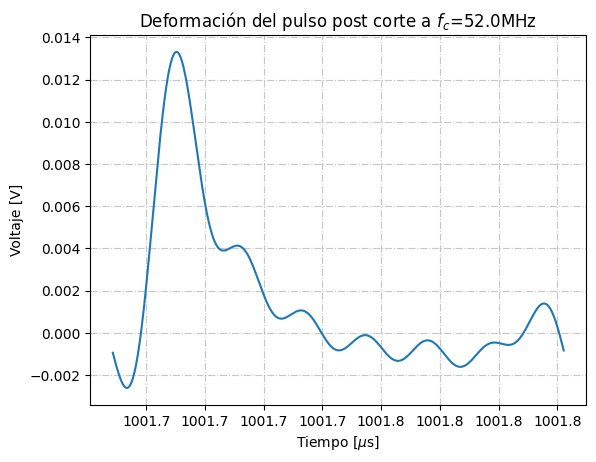

In [ ]:
ser_temp, ser_volt = dict_simples[i][0]['pulso_vent_t_v']
transf = transferencia(ser_volt, 8)
transf_t, transf_v, transf_frec = transf[1], transf[2], transf[3]

plt.xlabel('Tiempo [$\mu$s]')
plt.ylabel('Voltaje [V]')
formatterx = FuncFormatter(lambda x, _: f"{x*10**6:.1f}")
plt.gca().xaxis.set_major_formatter(formatterx)
plt.grid(linestyle='-.',alpha=.7)
plt.title('Deformación del pulso post corte a $f_{c}$='f'{round(transf_frec/10**6,1)}MHz')
plt.plot(transf_t,transf_v)

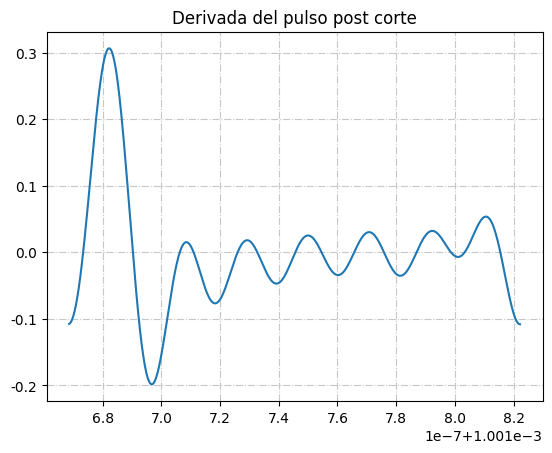

In [ ]:
plt.plot(transf_t,np.gradient(transf_v))
plt.title('Derivada del pulso post corte')
plt.grid(linestyle='-.',alpha=.7)
#formatterx = FuncFormatter(lambda x, _: f"{x*10/6:.1f}")
#plt.gca().xaxis.set_major_formatter(formatterx)
formattery = FuncFormatter(lambda x, _: f"{x*10**3:.1f}")
plt.gca().yaxis.set_major_formatter(formattery)

BATCH DE MEDICIONES SIMPLES

In [ ]:
carpeta = '/content/Extracto/2m/muons'
#carpeta = '/content/drive/MyDrive/Labo 6/Mediciones pipeta'
arch_dir = os.listdir(carpeta)
picos_dir = '/content/Picos ventanas'
pd.options.mode.copy_on_write = True

if not os.path.exists(picos_dir):
    os.makedirs(picos_dir)

# Diccionario para excepciones de archivos
excepciones_datos = {
    'C2muon-botti-2-1000000.csv': slice(1003, -1),
    # Agrega más excepciones según sea necesario
    'C1muon-botti-2-1000000.csv': slice(1003, -1),
}

# diccionario para estadistica de picos
dict_picos_arch = {}
#diccionario de mediciones simples
dict_simples = {}

# Diccionario para estadística de picos
dict_picos_arch = {}
dict_simples = {}

#quita archivos que estan mal ploteados
excepciones_csv = ['C1muon-botti-2-1000000.csv','C1muons-Botti-1610-1000Samples00000.csv']

for archivo in arch_dir:
    if (archivo.endswith('.csv') and archivo.startswith('C1') and archivo not in excepciones_csv):
        print(archivo)
        datos = pd.read_csv(os.path.join(carpeta, archivo), low_memory=False)
        datos.reset_index(inplace=True)
        # Seleccionar datos según el archivo y manejar excepciones
        if archivo in excepciones_datos:
            muones = datos[excepciones_datos[archivo]]
        else:
            muones = datos.iloc[103:]  # Tomar desde la fila 103

        muones.rename(columns={'index': 'custom_index'}, inplace=True)
        muones = muones.rename(columns={muones.columns[0]: "t", muones.columns[1]: "V"})
        muones.loc[:, 't'] = muones['t'].astype('float')
        muones.loc[:, 'V'] = muones['V'].astype('float')
        muones.drop(columns=[muones.columns[2], muones.columns[3]])
        delta_t = muones['t'].iloc[104] - muones['t'].iloc[103]
        tiempo = [i * delta_t for i in range(len(muones))]
        muones['t_0'] = pd.Series(tiempo)

        # Encuentra picos en los datos
        picos = find_peaks(muones['V'], prominence=0.03, distance=500)
        picos_v = picos[1]['prominences']
        picos_t = picos[0]

        picos_v_filtrados = picos_v[[i for i, t in enumerate(picos_t) if t in muones['t_0'].index]]
        picos_t_filtrados = picos_t[[i for i, t in enumerate(picos_t) if t in muones['t_0'].index]]

        plt.close()  # Cierra cualquier gráfico previo antes de iniciar uno nuevo
        plt.grid(linestyle='-.', alpha=0.7)
        plt.ylabel('Voltaje [V]')
        plt.xlabel(r'Tiempo [$\mu$s]')
        plt.plot(muones['t_0'], muones['V'])
        plt.plot(muones['t_0'][picos_t_filtrados], picos_v_filtrados, 'o')
        arch_sin_csv = archivo.split('.csv')[0]
        plt.savefig(f'/content/Picos ventanas/picos_csv_{arch_sin_csv}.png')

        # Estadísticas de picos
        dict_picos_arch[archivo] = [np.mean(picos_v), np.max(picos_v), np.min(picos_v), np.std(picos_v)]

        dict_ventanas = {}
        # Busca picos dentro de cada ventana
        for key_pulso in picos_t:
            borde_izq = 400
            if key_pulso < borde_izq:
                seccion = np.array(range(key_pulso, key_pulso + 1100))
                dict_muestras = {key_pulso: seccion}
            else:
                seccion = np.array(range(key_pulso - 400, key_pulso + 1100))
                dict_muestras = {key_pulso: seccion}

            # Ajustamos la selección de datos para cada ventana
            idx_inicio = dict_muestras[key_pulso][0] - muones.index[0]
            idx_fin = dict_muestras[key_pulso][-1] - muones.index[0] + 1

            pulso_t_0 = muones['t_0'].iloc[idx_inicio:idx_fin]
            pulso_v = muones['V'].iloc[idx_inicio:idx_fin]
            #picos_ventana = find_peaks(pulso_v, prominence=0.01)               #funciona
            picos_ventana = find_peaks(pulso_v,prominence=0.005)
            # Solo para debugging
            # print(key_pulso, 'Cantidad de picos por ventana:', len(picos_ventana[0]))
            if len(picos_ventana[0]) == 1:
                plt.close()  # Cierra cualquier gráfico previo antes de iniciar uno nuevo
                plt.grid(linestyle='-.', alpha=0.7)
                plt.ylabel('Voltaje [V]')
                plt.xlabel(r'Tiempo [$\mu$s]')
                plt.plot(pulso_t_0, pulso_v)
                picos_vent_v = picos_ventana[1]['prominences']
                picos_vent_t = picos_ventana[0]
                plt.scatter(pulso_t_0.iloc[picos_vent_t], pulso_v.iloc[picos_vent_t], color='red', zorder=99)
                n_arch = archivo.split('.csv')[0]
                plt.savefig(f'/content/Picos ventanas/pico_{n_arch}_{key_pulso}.png')
                dict_ventanas[key_pulso] = picos_ventana[0]
                #dict_simples[archivo] = pulso_t_0.iloc[picos_vent_t].index
                dict_simples[archivo] = {key_pulso: pulso_t_0.iloc[picos_vent_t].index, 'pulso_vent_t_v': [pulso_t_0,pulso_v]}



#dict_simples

# # Muestra el diccionario de estadísticas de picos por archivo
# print("Estadísticas de picos por archivo:")
# for archivo, estadisticas in dict_picos_arch.items():
#     print(f"Archivo: {archivo}, Estadísticas: {estadisticas}")

# # Muestra el diccionario de picos por ventana
# print("Picos por ventana:")
# for ventana, picos in dict_ventanas.items():
#     print(f"Ventana: {ventana}, Picos: {picos}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Extracto/2m/muons'

In [ ]:
rs =  risetime(t_array,v_array)

plt.plot(t_array,v_array)
plt.grid(linestyle='-.',alpha=.7)
plt.plot(t_array[rs[1][0]:rs[1][2]],v_array[rs[1][0]:rs[1][2]],color='green',zorder=99)
# plt.title('Selección de Rise-Time')
# plt.xlabel('Tiempo [$\mu$s]')
# plt.ylabel('Tensión [V]')
# formatterx = FuncFormatter(lambda x, _: f"{x*10**6:.1f}")
# plt.gca().xaxis.set_major_formatter(formatterx)
# plt.text(4.5*10**-7,0.11,f'Rise-Time de {rs[0]}s')

NameError: name 't_array' is not defined